In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Задание 1. По номеру варианта определить из таблицы 1 тип входных данных, которые надо программно сгенерировать для дальнейшей обработки, и номера алгоритмов, которые следует применить к этим данным.

###### вариант = 6, номер типа входных данных = 6, номер алгоритмов = 1, 3

### Задание 2. Определить из таблицы 2 вид входных данных, которые должны быть обработаны. Программно сгенерировать эти данные, вывести их в виде графика (диаграммы разброса). Количество прецедентов должно задаваться одной из переменных программы, чтобы допустить лёгкое изменение в процессе тестирования. Регрессионные модели должны предсказывать значения последней из координат точек по остальным.

###### Точки трехмерного пространства вида (x, y, x**2+y), где значения x — нормально распределенные случайные числа со средним 1 и среднеквадратическим отклонеием 1, значения y — случайные числа, равномерно распределенные по отрезку [−1, 1]

### Задание 3. Определить по таблице 3 методы обработки данных. Следует обработать выборку каждым из методов по отдельности и сравнить точности полученных регрессионных моделей (среднеквадратические значения ошибок на использованных выборках). Значения настроечных коэффициентов, если они требуются, следует выбрать самостоятельно; нулевые значения этих коэффициентов не допускаются.

###### 1. Линейная регрессия или полиномиальная регрессия (по выбору студента)

###### 3. RANSAC

In [3]:
import random
import seaborn as sns

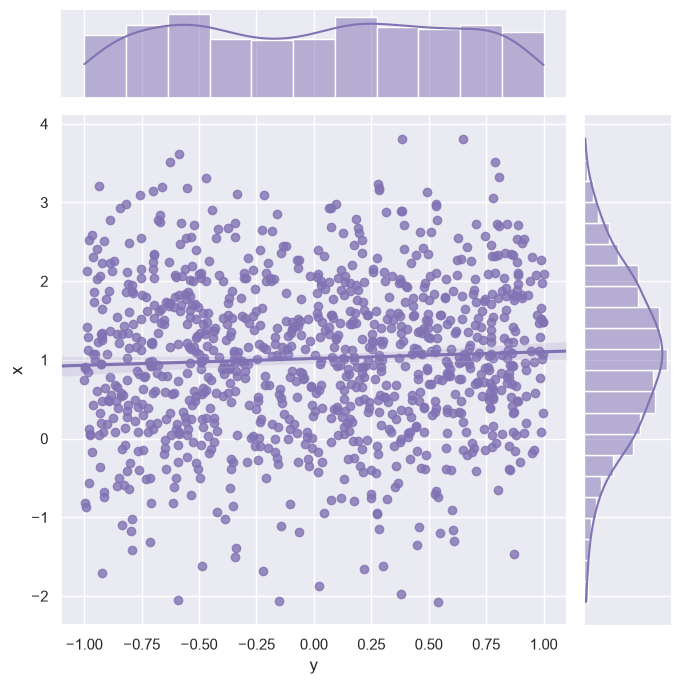

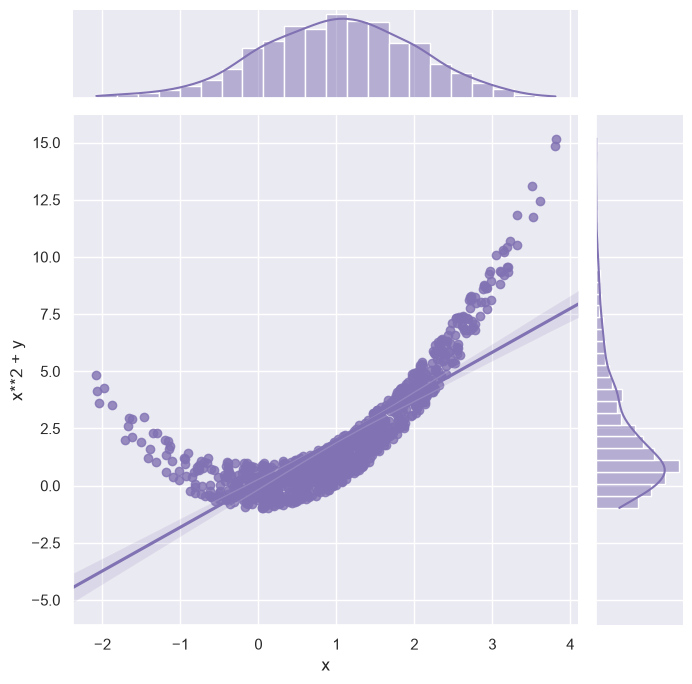

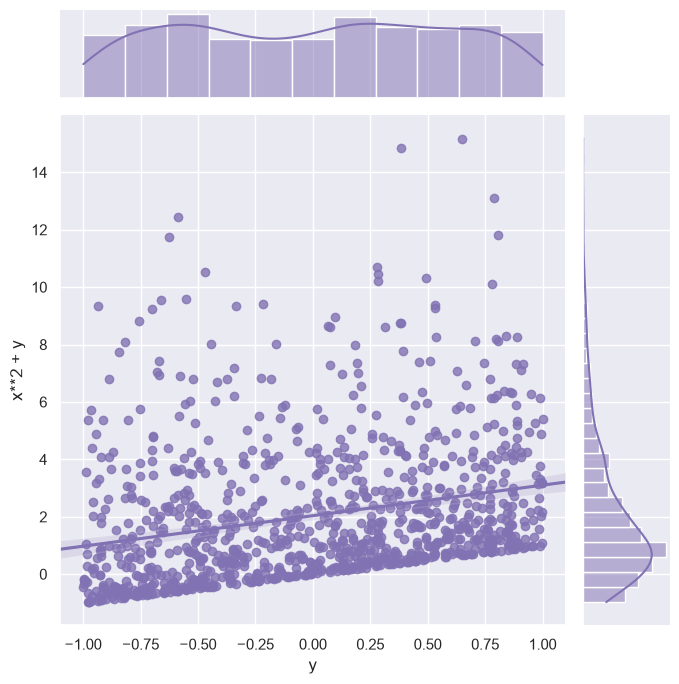

In [4]:
#Функция, которая генерирует выборку
def generate_data(sample_size: int) -> pd.DataFrame:
    data_list = [[] for _ in range(sample_size)]
    for num in range(sample_size):
        x = random.normalvariate(mu = 1, sigma = 1)
        y = random.uniform(a = -1, b = 1)
        xsq_y = x**2 + y
        data_list[num] = [x,y,xsq_y]
    df = pd.DataFrame(data = data_list, columns = ['x','y','x**2 + y'])
    return df
df=generate_data(1000)

#Диаграмма разброса
def generate_g(argument_x: str, argument_y: str, df: pd.DataFrame) -> None:
    df = df[[argument_x, argument_y]]
    sns.set_theme(style="darkgrid")
    sns.jointplot(x =argument_x, y = argument_y, data = df, kind = "reg", truncate = False, color = "m", height= 7)


generate_g('y', 'x', df)
generate_g('x', 'x**2 + y', df)
generate_g('y', 'x**2 + y', df)

    

In [21]:
#Дополнительная визуализация 3D
from mpl_toolkits.mplot3d import axes3d, Axes3D

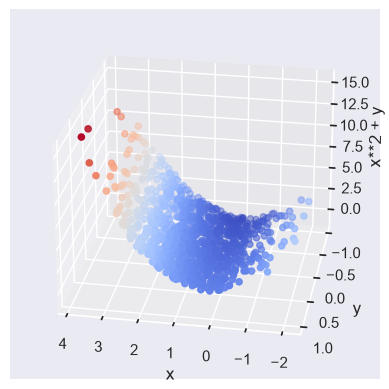

In [5]:
def fig_3d(df: pd.DataFrame)->None:
    ax = plt.figure().add_subplot(projection='3d')
    ax.scatter(df['x'],df['y'],df['x**2 + y'], c=df['x**2 + y'],cmap='coolwarm')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('x**2 + y')
    ax.view_init(elev=25, azim=100, roll=0)

    plt.show()

fig_3d(df)

### Один из двух алгоритмов по выбору студента должен быть реализован без использования готовых процедур используемой библиотеки машинного обучения (разрешается применять только готовые методы матричной арифметики).

###### Реализация полиномиальной регрессии без использования готовых процедур

In [ ]:
#Разделим выборку на test n train
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.2, train_size=0.8)

In [10]:
train.describe()

,x,y,x**2 + y
count,800.000000,800.000000,800.000000
mean,1.023105,0.011747,2.079344
std,1.011005,0.576502,2.493421
min,-2.067553,-0.999434,-0.973289
25%,0.353898,-0.507250,0.417089
50%,1.024812,0.064847,1.280078
75%,1.708413,0.492809,3.076862
max,3.810896,0.999951,15.171063


In [ ]:
#Реализация модели
def train_polinom_regression(train: pd.DataFrame):
    Y = train[['x**2 + y']].to_numpy()
    x_val = train['x'].to_numpy()
    y_val = train['y'].to_numpy()

    X = np.column_stack([
        np.ones_like(x_val),
        x_val,
        y_val,
        x_val**2,
        y_val**2,
        x_val * y_val,
    ])    
    #XC=Y, X=(1,x,y,x**2,y**2,x*y), C=(X**TdotX)**-1 dotX.T dotΖ

    C=np.linalg.inv(X.T @ X) @ X.T @ Y
    return C

def MSE(y_true: list[int], y_pred: list[int]) -> int:
    return np.mean((y_true - y_pred) ** 2)

def test_pred_polinom_regression(test: pd.DataFrame, C: np.array):
    Y = test[['x**2 + y']].to_numpy()
    x_val = test['x'].to_numpy()
    y_val = test['y'].to_numpy()


    X = np.column_stack([
        np.ones_like(x_val),
        x_val,
        y_val,
        x_val**2,
        y_val**2,
        x_val * y_val,
    ]) 

    Y_pred = X @ C

    return Y, Y_pred

C_coeff = train_polinom_regression(train)
Y, Y_pred = test_pred_polinom_regression(test, C_coeff)
print("MSE: ", MSE(y_true= Y, y_pred= Y_pred))



MSE:  2.9425392915309117e-30


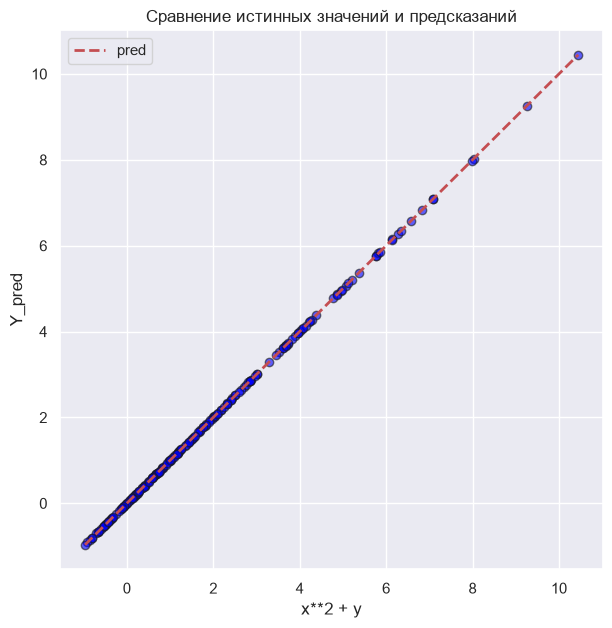

In [35]:
#Визуализация
def plot_true_vs_pred(y_true: np.ndarray, y_pred: np.ndarray):
    plt.figure(figsize=(7, 7))

    plt.scatter(y_true, y_pred, alpha=0.6, color='blue', edgecolors='k')
    
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='pred')
    
    plt.xlabel('x**2 + y')
    plt.ylabel('Y_pred')
    plt.title('Сравнение истинных значений и предсказаний')

    plt.legend()
    plt.grid(True)

    plt.show()


plot_true_vs_pred(test[['x**2 + y']].to_numpy(), Y_pred)

###### Реализация RANSAC с помощью библиотеки scikit-learn

In [ ]:
from sklearn.linear_model import RANSACRegressor, LinearRegression
def train_ransac(train: pd. DataFrame):
    Y = train[['x**2 + y']].to_numpy()
    x_val = train['x'].to_numpy()
    y_val = train['y'].to_numpy()

    X = np.column_stack([
        np.ones_like(x_val),
        x_val,
        y_val,
        x_val**2,
        y_val**2,
        x_val * y_val,
    ])

    '''
    RANSAC устойчива к выбросам и находит параметры модели на основе итеративного алгоритма:
    1) Случайным образом выбирает минимально необходимое подмножество
       исходных данных (Inliers) и строит на них базовую модель;
    2) Оценивает остальные точки выборки: точки, ошибка предсказания
       для которых не превышает порог residual_threshold, также объявляются инлайерами;
    3) Повторяет процесс max_trials раз и выбирает ту модель, которая собрала
       наибольшее количество инлайеров (или показала наименьшую ошибку среди них);
    4) Финально переобучает базовую регрессию (по умолчанию LinearRegression)
       исключительно на всем найденном множестве инлайеров, отбрасывая выбросы (Outliers)
    '''
    model = RANSACRegressor(
        estimator= LinearRegression(),    #Базовая модель для обучения
        min_samples = 10,                 #Мин кличество точек для построения модели на итерации
        residual_threshold = 0.01,        #Порог разделения на Inliners и Outliners (нужно для работы с шумом)
        max_trials = 100,                 #Макс число итераций
        random_state= 42,                 #Фиксация случайности для воспроизводимости
        
    )

    model.fit(X, Y)
    
    return model
   

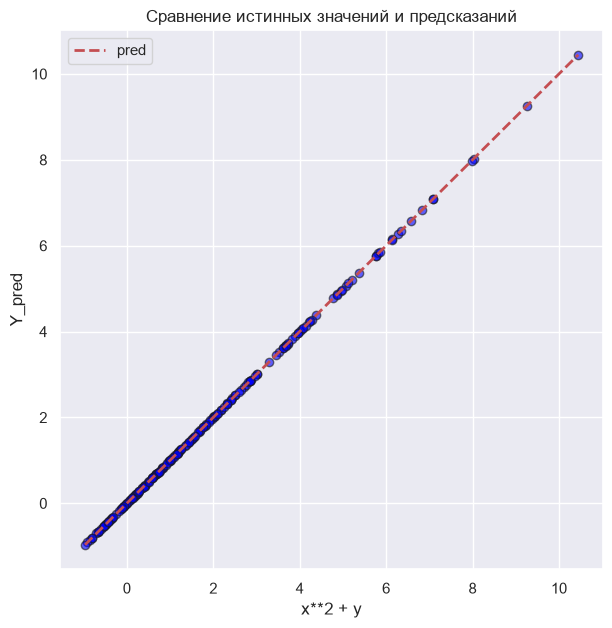

MSE:  1.14621299343031e-30


In [54]:
model = train_ransac(train)
def gen_X_Y_test(test):
    Y = test[['x**2 + y']].to_numpy()
    x_val = test['x'].to_numpy()
    y_val = test['y'].to_numpy()

    X_test = np.column_stack([
        np.ones_like(x_val),
        x_val,
        y_val,
        x_val**2,
        y_val**2,
        x_val * y_val,
    ])
    return Y, X_test

Y, X_test = gen_X_Y_test(test)

Y_pred = model.predict(X_test)

plot_true_vs_pred(Y,Y_pred)
mse = MSE(y_true= Y, y_pred= Y_pred)
print("MSE: ", mse)


### Задание 4. Создать новую выборку данных такого же размера и сравнить точность моделей на старой и новой выборках. Сделать вывод о сохранении точностных характеристик каждой из моделей.

In [ ]:
#Полиноминальная регрессия
df1=generate_data(100000)
df2=generate_data(100000)

train1, test1 = train_test_split(df1, test_size=0.2, train_size=0.8)
train2, test2 = train_test_split(df2, test_size=0.2, train_size=0.8)

C_coeff1 = train_polinom_regression(train1)
Y1, Y_pred1 = test_pred_polinom_regression(test1, C_coeff1)

C_coeff2 = train_polinom_regression(train2)
Y2, Y_pred2 = test_pred_polinom_regression(test2, C_coeff2)


mse1 = MSE(y_true= Y1, y_pred= Y_pred1)
mse2= MSE(y_true= Y2, y_pred= Y_pred2)
print("MSE1: ", mse1)
print("MSE2: ", mse2)

print("Отличие MSE: ", abs(mse1-mse2))
#При генерации новой выборки MSE практически не отличается


MSE1:  5.877461186807268e-29
MSE2:  1.8947488226028765e-29
Отличие MSE:  3.982712364204391e-29


In [55]:
#RANSAC
df1=generate_data(100000)
df2=generate_data(100000)

train1, test1 = train_test_split(df1, test_size=0.2, train_size=0.8)
train2, test2 = train_test_split(df2, test_size=0.2, train_size=0.8)

Y1, X_test1 = gen_X_Y_test(test1)
Y_pred1 = model.predict(X_test1)

Y2, X_test2 = gen_X_Y_test(test2)
Y_pred2 = model.predict(X_test2)


mse1 = MSE(y_true= Y1, y_pred= Y_pred1)
mse2= MSE(y_true= Y2, y_pred= Y_pred2)
print("MSE1: ", mse1)
print("MSE2: ", mse2)

print("Отличие MSE: ", abs(mse1-mse2))
#При генерации новой выборки MSE практически не отличается

MSE1:  1.5073623634556856e-30
MSE2:  1.4598223682988707e-30
Отличие MSE:  4.753999515681485e-32
